<a href="https://colab.research.google.com/github/dkilian01/Testowanie_01/blob/main/Testowanie01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Testy jednostkowe algorytmów sortowania i analiza pokrycia kodu**

## **Cel notatki**
Celem notatki jest zaprezentowanie testowania dwóch alogrytmów sortowania wraz z wykorzystaniem narzedzi coverage.

Zaimplementowano dwa algoyrtmy sorotwania:

*   insertion_sort — złożoność O(n²),
*   merge_sort — złożoność O(n log n),

Następnie przygotowano testy w unittest i uruchomono je, użytko narzędzia coverage z pomiarem statement coverage i branch coverage.



In [ ]:
%%writefile sorting_algorithms.py
"""
Plik z dwoma algorytmmi sortowania. Wykorzystany z własnego githuba (https://github.com/dkilian01/Testowanie_01/blob/main/sorting_algorithms.py)
Zawiera algorytmy sortowania:
    -insert_sort
    -merger_sort
Wraz z funkcją do sprawdzenia danych wejsciowych.
"""
from typing import Iterable, List, Any
def _validate_sort_input(data: Iterable[Any]) -> List[Any]:
    """
    Sprawdza, czy dane wejściowe można posortować.

    Funkcja zwraca kopię danych jako listę, aby algorytmy sortujące
    nie modyfikowały oryginalnej kolekcji przekazanej przez użytkownika.

    Args:
        data: Kolekcja elementów do posortowania.

    Returns:
        Lista elementów do dalszego sortowania.

    Raises:
        TypeError: Gdy data jest None, tekstem albo obiektem nieiterowalnym.
    """
    if data is None:
        raise TypeError("Dane wejściowe nie mogą być puste.")

    if isinstance(data, (str, bytes)):
        raise TypeError("Dane wejściowe nie mogą być tekstem ani bajtami.")

    try:
        return list(data)
    except TypeError as exc:
        raise TypeError("Dane wejściowe muszą być iterowalne.") from exc


def insertion_sort(data: Iterable[Any]) -> List[Any]:
    """
    Sortowanie przez wstawianie.

    Jest to algorytm o złożoności obliczeniowej O(n^2).
    Dobrze nadaje się do pokazania prostego algorytmu sortowania
    oraz testowania pętli i przypadków brzegowych.

    Args:
        data: Kolekcja elementów do posortowania.

    Returns:
        Nowa lista zawierająca posortowane elementy.
    """
    result = _validate_sort_input(data)

    for i in range(1, len(result)):
        key = result[i]
        j = i - 1

        while j >= 0 and result[j] > key:
            result[j + 1] = result[j]
            j -= 1

        result[j + 1] = key

    return result


def merge_sort(data: Iterable[Any]) -> List[Any]:
    """
    Sortowanie przez scalanie.

    Jest to algorytm o złożoności obliczeniowej O(n log n).
    Algorytm dzieli listę na mniejsze części, sortuje je rekurencyjnie,
    a następnie scala w jedną uporządkowaną listę.

    Args:
        data: Kolekcja elementów do posortowania.

    Returns:
        Nowa lista zawierająca posortowane elementy.
    """
    result = _validate_sort_input(data)

    if len(result) <= 1:
        return result

    middle = len(result) // 2
    left = merge_sort(result[:middle])
    right = merge_sort(result[middle:])

    return _merge(left, right)


def _merge(left: List[Any], right: List[Any]) -> List[Any]:
    """
    Scala dwie posortowane listy w jedną posortowaną listę.

    Funkcja pomocnicza używana przez merge_sort.

    Args:
        left: Lewa posortowana lista.
        right: Prawa posortowana lista.

    Returns:
        Posortowana lista zawierająca elementy z left i right.
    """
    result = []
    i = 0
    j = 0

    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1

    while i < len(left):
        result.append(left[i])
        i += 1

    while j < len(right):
        result.append(right[j])
        j += 1

    return result


Writing sorting_algorithms.py


# Zakres przerpowadzonych testów
Testy obejmują :

*   Pustą listę
*   Listę posortowaną
*   Listę jednoelementową
*   Listę w odwortnej kolejności
*   Listę z duplikatami
*   Liczby ujemne i zero
*   Krotkę jako dane wejscowe
*   Listę generowaną
*   Listę napisów
*   Sprawdzenie czy originalna list była modyfikowana
*   Porównanie wyniku z funkcją wbudowaną "sorted"
*   Błędne dane wjeściowe: None i nieiterowalna wartość
*   Testy funkcji _merge w celu pokrycja scalania merge_sort




In [ ]:
!pip -q install coverage


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.6/254.6 kB 3.1 MB/s eta 0:00:00


In [ ]:
%%writefile test_sorting.py
"""
Plik z testami sortowania. Wykorzystany z własnego githuba (https://github.com/dkilian01/Testowanie_01/blob/main/test_sorting.py)
"""

import unittest

from sorting_algorithms import insertion_sort, merge_sort, _merge


SORTING_FUNCTIONS = [
    insertion_sort,
    merge_sort,
]


class TestSortingAlgorithms(unittest.TestCase):
    """
    Testy jednostkowe dla obu algorytmów sortowania.
    Te same przypadki są wykonywane dla insertion_sort oraz merge_sort.
    """

    def test_empty_list(self):
        for sort_function in SORTING_FUNCTIONS:
            with self.subTest(sort_function=sort_function.__name__):
                self.assertEqual(sort_function([]), [])

    def test_single_element(self):
        for sort_function in SORTING_FUNCTIONS:
            with self.subTest(sort_function=sort_function.__name__):
                self.assertEqual(sort_function([5]), [5])

    def test_already_sorted_list(self):
        for sort_function in SORTING_FUNCTIONS:
            with self.subTest(sort_function=sort_function.__name__):
                self.assertEqual(sort_function([1, 2, 3, 4, 5]), [1, 2, 3, 4, 5])

    def test_reverse_sorted_list(self):
        for sort_function in SORTING_FUNCTIONS:
            with self.subTest(sort_function=sort_function.__name__):
                self.assertEqual(sort_function([5, 4, 3, 2, 1]), [1, 2, 3, 4, 5])

    def test_unsorted_list(self):
        for sort_function in SORTING_FUNCTIONS:
            with self.subTest(sort_function=sort_function.__name__):
                self.assertEqual(sort_function([4, 2, 5, 1, 3]), [1, 2, 3, 4, 5])

    def test_duplicates(self):
        for sort_function in SORTING_FUNCTIONS:
            with self.subTest(sort_function=sort_function.__name__):
                self.assertEqual(sort_function([3, 1, 2, 3, 1]), [1, 1, 2, 3, 3])

    def test_negative_numbers(self):
        for sort_function in SORTING_FUNCTIONS:
            with self.subTest(sort_function=sort_function.__name__):
                self.assertEqual(sort_function([-1, -5, 3, 0, 2]), [-5, -1, 0, 2, 3])

    def test_float_numbers(self):
        for sort_function in SORTING_FUNCTIONS:
            with self.subTest(sort_function=sort_function.__name__):
                self.assertEqual(sort_function([2.5, 1.1, 3.3, 1.0]), [1.0, 1.1, 2.5, 3.3])

    def test_tuple_input(self):
        for sort_function in SORTING_FUNCTIONS:
            with self.subTest(sort_function=sort_function.__name__):
                self.assertEqual(sort_function((3, 2, 1)), [1, 2, 3])

    def test_generator_input(self):
        for sort_function in SORTING_FUNCTIONS:
            with self.subTest(sort_function=sort_function.__name__):
                data = (number for number in [3, 1, 2])
                self.assertEqual(sort_function(data), [1, 2, 3])

    def test_original_list_is_not_modified(self):
        for sort_function in SORTING_FUNCTIONS:
            with self.subTest(sort_function=sort_function.__name__):
                data = [3, 1, 2]
                sorted_data = sort_function(data)

                self.assertEqual(sorted_data, [1, 2, 3])
                self.assertEqual(data, [3, 1, 2])

    def test_none_input_raises_type_error(self):
        for sort_function in SORTING_FUNCTIONS:
            with self.subTest(sort_function=sort_function.__name__):
                with self.assertRaises(TypeError):
                    sort_function(None)

    def test_string_input_raises_type_error(self):
        for sort_function in SORTING_FUNCTIONS:
            with self.subTest(sort_function=sort_function.__name__):
                with self.assertRaises(TypeError):
                    sort_function("321")

    def test_non_iterable_input_raises_type_error(self):
        for sort_function in SORTING_FUNCTIONS:
            with self.subTest(sort_function=sort_function.__name__):
                with self.assertRaises(TypeError):
                    sort_function(123)

    def test_mixed_uncomparable_types_raise_type_error(self):
        for sort_function in SORTING_FUNCTIONS:
            with self.subTest(sort_function=sort_function.__name__):
                with self.assertRaises(TypeError):
                    sort_function([1, "a", 3])


class TestMergeHelper(unittest.TestCase):
    """
    Testy funkcji pomocniczej _merge.
    """

    def test_merge_two_non_empty_lists(self):
        self.assertEqual(_merge([1, 3, 5], [2, 4, 6]), [1, 2, 3, 4, 5, 6])

    def test_merge_when_left_has_remaining_elements(self):
        self.assertEqual(_merge([1, 2, 10], [3]), [1, 2, 3, 10])

    def test_merge_when_right_has_remaining_elements(self):
        self.assertEqual(_merge([3], [1, 2, 10]), [1, 2, 3, 10])

    def test_merge_empty_left_list(self):
        self.assertEqual(_merge([], [1, 2, 3]), [1, 2, 3])

    def test_merge_empty_right_list(self):
        self.assertEqual(_merge([1, 2, 3], []), [1, 2, 3])


if __name__ == "__main__":
    unittest.main()

Writing test_sorting.py


In [ ]:
!python -m unittest -v test_sorting.py

test_merge_empty_left_list (test_sorting.TestMergeHelper.test_merge_empty_left_list) ... ok
test_merge_empty_right_list (test_sorting.TestMergeHelper.test_merge_empty_right_list) ... ok
test_merge_two_non_empty_lists (test_sorting.TestMergeHelper.test_merge_two_non_empty_lists) ... ok
test_merge_when_left_has_remaining_elements (test_sorting.TestMergeHelper.test_merge_when_left_has_remaining_elements) ... ok
test_merge_when_right_has_remaining_elements (test_sorting.TestMergeHelper.test_merge_when_right_has_remaining_elements) ... ok
test_already_sorted_list (test_sorting.TestSortingAlgorithms.test_already_sorted_list) ... ok
test_duplicates (test_sorting.TestSortingAlgorithms.test_duplicates) ... ok
test_empty_list (test_sorting.TestSortingAlgorithms.test_empty_list) ... ok
test_float_numbers (test_sorting.TestSortingAlgorithms.test_float_numbers) ... ok
test_generator_input (test_sorting.TestSortingAlgorithms.test_generator_input) ... ok
test_mixed_uncomparable_types_raise_type_error

# Wykorzystanie coverage
W poniższym teście używamy parametru `branch`, ponieważ poza zwykłym pokrycjem instrukcji chcemy sprawdzić także pokrycje gałęzi. Parametr
`--source=sorting_algorithms` ogranicza raport do kodu właściwego programu, czyli algorytmów sortowania bez plików testów.






In [ ]:
!coverage erase
!coverage run --branch --source=sorting_algorithms -m unittest -v test_sorting.py
!coverage report -m
!coverage html -d htmlcov

test_merge_empty_left_list (test_sorting.TestMergeHelper.test_merge_empty_left_list) ... ok
test_merge_empty_right_list (test_sorting.TestMergeHelper.test_merge_empty_right_list) ... ok
test_merge_two_non_empty_lists (test_sorting.TestMergeHelper.test_merge_two_non_empty_lists) ... ok
test_merge_when_left_has_remaining_elements (test_sorting.TestMergeHelper.test_merge_when_left_has_remaining_elements) ... ok
test_merge_when_right_has_remaining_elements (test_sorting.TestMergeHelper.test_merge_when_right_has_remaining_elements) ... ok
test_already_sorted_list (test_sorting.TestSortingAlgorithms.test_already_sorted_list) ... ok
test_duplicates (test_sorting.TestSortingAlgorithms.test_duplicates) ... ok
test_empty_list (test_sorting.TestSortingAlgorithms.test_empty_list) ... ok
test_float_numbers (test_sorting.TestSortingAlgorithms.test_float_numbers) ... ok
test_generator_input (test_sorting.TestSortingAlgorithms.test_generator_input) ... ok
test_mixed_uncomparable_types_raise_type_error

In [ ]:
from IPython.display import display, HTML

with open("htmlcov/index.html", "r", encoding="utf-8") as f:
    display(HTML(f.read()))

# Wyniki

Raport pokazuje 100% pokrycja dla pliku sorting_algorithms.py:

*   Statements oznacza ilośc analizowanych instrukcji w pliku,
*   Miss oznacza ilość pominiętych instrukcji,
*   Branch to liczba analizowanych gałęzi,
*   BrPart to liczba częsciowo pkrytych gałęzi,
*   Cover to wartość pokrycja dla badanego modułu.

W praktyce po naszych wynikach widaćze testy uruchomiły wszystkie instrukcjię wszystkie wykryte przez coverage gałęzie. Oanzacza to że przy tym testowaniu wszystkie wybrane przypadki działają poprawnie.



# Analiza wydajnościowa algorytmów sortowania

W tej części porównujemy czas działania dwóch algorytmów sortowania przygotowanych w poprzednim zadaniu:

Dane wejściowe są losowymi tablicami liczb całkowitych.  
Pomiar czasu wykonania realizowany jest narzędziem `pytest-benchmark`.

Dla obu algorytmów wykonujemy pomiary dla rozmiarów:

- 10,
- 100,
- 1000,
- 5000,
- 10000,
- 100000.

Dla `insertion_sort` rozmiar 100000 elementów test będzie trwał długo ponieważ jego złożoność jest O(n²).

In [1]:
!pip -q install pytest pytest-benchmark pandas matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Nailik\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
%%writefile test_benchmark.py
import random
import pytest

from sorting_algorithms import insertion_sort, merge_sort


def generate_random_data(size, seed=12345):
    """
    Generuje losową listę liczb całkowitych.

    Seed zależy od rozmiaru danych, aby wyniki były powtarzalne.
    Dzięki temu dla danego rozmiaru zawsze powstaje ten sam zestaw danych.
    """
    rng = random.Random(seed + size)
    return [rng.randint(-1_000_000, 1_000_000) for _ in range(size)]


COMMON_SIZES = [10, 100, 1000, 5000, 10000, 100000]

BENCHMARK_CASES = []

for size in COMMON_SIZES:
    BENCHMARK_CASES.append(("insertion_sort", size))
    BENCHMARK_CASES.append(("merge_sort", size))


ALGORITHMS = {
    "insertion_sort": insertion_sort,
    "merge_sort": merge_sort,
}


@pytest.mark.parametrize("algorithm_name,size", BENCHMARK_CASES)
def test_sorting_performance(benchmark, algorithm_name, size):
    """
    Test wydajnościowy algorytmów sortowania.

    benchmark.pedantic pozwala kontrolować liczbę rund pomiarowych.
    Dla każdego przypadku sprawdzamy również poprawność wyniku,
    porównując rezultat z wbudowaną funkcją sorted().
    """
    sort_function = ALGORITHMS[algorithm_name]
    data = generate_random_data(size)

    result = benchmark.pedantic(
        sort_function,
        args=(data,),
        rounds=3,
        iterations=1
    )

    assert result == sorted(data)

Overwriting test_benchmark.py


In [6]:
!pytest -q test_benchmark.py --benchmark-only --benchmark-json=benchmark_results.json

............                                                             [100%]

---------------------------------------------------------------------------------------------------------------------------- benchmark: 12 tests -----------------------------------------------------------------------------------------------------------------------------
Name (time in us)                                                Min                         Max                        Mean                     StdDev                      Median                        IQR            Outliers           OPS            Rounds  Iterations
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
test_sorting_performance[insertion_sort-10]                   2.9000 (1.0)                7.3000 (1.0)    


Wrote benchmark data in: <_io.BufferedWriter name='benchmark_results.json'>


In [1]:
import json
import re
import pandas as pd

with open("benchmark_results.json", "r", encoding="utf-8") as file:
    benchmark_data = json.load(file)

rows = []

for benchmark in benchmark_data["benchmarks"]:
    params = benchmark.get("params", {})

    algorithm_name = params.get("algorithm_name")
    size = params.get("size")


    # gdyby dana wersja pytest-benchmark nie zapisała ich w params.
    if algorithm_name is None or size is None:
        name = benchmark.get("name", "")
        match = re.search(r"\[(.+)-(\d+)\]", name)

        if match:
            algorithm_name = match.group(1)
            size = int(match.group(2))

    stats = benchmark["stats"]

    rows.append({
        "algorytm": algorithm_name,
        "liczba_elementow": int(size),
        "sredni_czas_s": stats["mean"],
        "sredni_czas_ms": stats["mean"] * 1000,
        "min_s": stats["min"],
        "max_s": stats["max"],
        "mediana_s": stats["median"],
        "odchylenie_std_s": stats["stddev"],
        "liczba_rund": stats["rounds"],
    })

df = pd.DataFrame(rows)
df = df.sort_values(["liczba_elementow", "algorytm"]).reset_index(drop=True)

df

,algorytm,liczba_elementow,sredni_czas_s,sredni_czas_ms,min_s,max_s,mediana_s,odchylenie_std_s,liczba_rund
0,insertion_sort,10,0.000005,0.004733,0.000003,0.000007,0.000004,0.000002,3
1,merge_sort,10,0.000013,0.013233,0.000010,0.000019,0.000010,0.000005,3
2,insertion_sort,100,0.000121,0.121433,0.000120,0.000123,0.000122,0.000001,3
3,merge_sort,100,0.000138,0.138200,0.000134,0.000141,0.000140,0.000004,3
4,insertion_sort,1000,0.016931,16.931200,0.016029,0.017965,0.016800,0.000975,3
5,merge_sort,1000,0.001733,1.732767,0.001707,0.001768,0.001723,0.000032,3
6,insertion_sort,5000,0.437741,437.740733,0.433526,0.443298,0.436398,0.005023,3
7,merge_sort,5000,0.010480,10.480167,0.010377,0.010578,0.010486,0.000101,3
8,insertion_sort,10000,1.756838,1756.838333,1.729395,1.780852,1.760268,0.025899,3
9,merge_sort,10000,0.022866,22.865800,0.022312,0.023416,0.022869,0.000552,3


In [2]:
pivot_df = df.pivot(
    index="liczba_elementow",
    columns="algorytm",
    values="sredni_czas_ms"
)

pivot_df

algorytm,insertion_sort,merge_sort
liczba_elementow,,
10,0.004733,0.013233
100,0.121433,0.138200
1000,16.931200,1.732767
5000,437.740733,10.480167
10000,1756.838333,22.865800
100000,217510.802933,283.773633


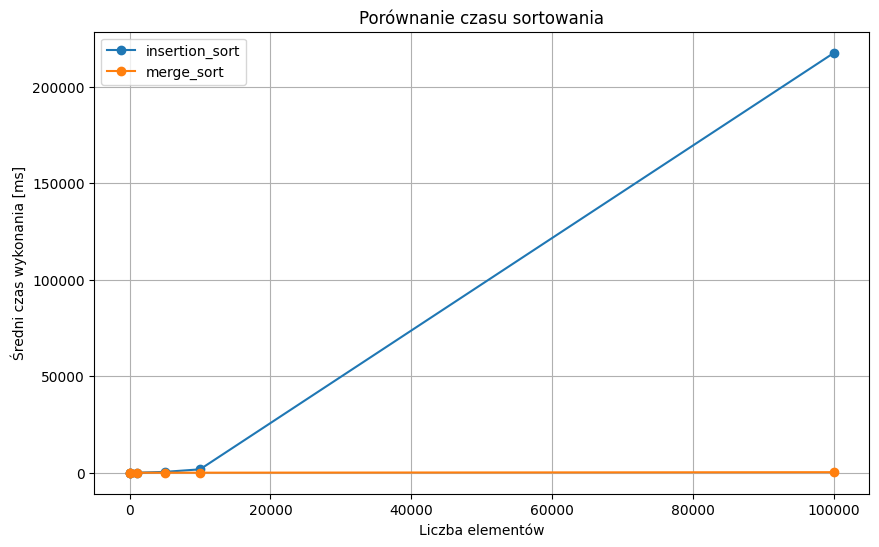

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for algorithm in pivot_df.columns:
    plt.plot(
        pivot_df.index,
        pivot_df[algorithm],
        marker="o",
        label=algorithm
    )

plt.title("Porównanie czasu sortowania")
plt.xlabel("Liczba elementów")
plt.ylabel("Średni czas wykonania [ms]")
plt.legend()
plt.grid(True)
plt.show()